# CLERO quickstart

Predict a planet's climate and have a look

In [1]:
%matplotlib inline
import numpy as np

from clero import Emulator
from clero.climate_analysis import latitude_centers, field_map, plot_profile

## Inputs

(See [README](../README.md) for details and [SCOPE](../SCOPE.md) for the valid range.)

In [2]:
INPUTS = {
    "T_star": 3000.0,     # K
    "F_star": 1500.0,     # W/m^2
    "radius": 1.0,        # Earth radii
    "gravity": 10.0,       # m/s^2
    "P_rot": 10.0,        # days
    "P0": 1.0,            # bar
    "CO2": 0.0,        # volume fraction
    "CH4": 0.0,           # volume fraction
    "GCM": "um",          # target GCM (optional; defaults to "um")
}

emu = Emulator()

## Predict and plot

`predict` returns one 32×64 field per output, keyed by name. `field_map` is a quick look at any 2D field; `plot_profile` shows the vertical global-mean profile for a 3D variable.

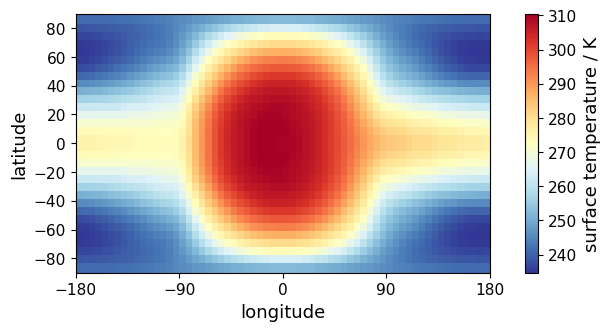

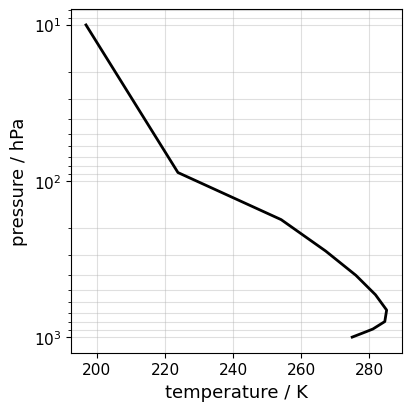

In [3]:
climate = emu.predict(INPUTS) # the mean of CLERO's climate distribution 
lat = latitude_centers(climate["surface_temperature"].shape[0])

fig, ax = field_map(climate, "surface_temperature", lat=lat, units="surface temperature / K")
fig, ax = plot_profile(climate, "temperature", lat=lat, P0=INPUTS["P0"], units="temperature / K")

## Variance

`return_variance=True` adds the per-grid-cell marginal predictive variance in model space (see [README](../README.md))

In [4]:
mean_m, variance_m = emu.predict(INPUTS, space="model", return_variance=True)
std_m = np.sqrt(variance_m["surface_temperature"])
print(f"surface model-space std (min, median, max) = ({std_m.min():.2f}, {np.median(std_m):.2f}, {std_m.max():.2f})")

surface model-space std (min, median, max) = (8.04, 9.03, 10.79)


## Predictive samples

`sample` draws climates from CLERO's climate distribution. See [`using_clero_samples.ipynb`](using_clero_samples.ipynb) for more.

In [5]:
samples = emu.sample(INPUTS, n_samples=256, seed=0)
samples["asr"].shape

(256, 32, 64)

## Where next

- `trappist1e.ipynb` — a full single-planet report: maps, summaries, profiles, export.
- `using_clero_samples.ipynb` — predictive samples, skewed-field summaries, batched/GPU sampling.
- `parameter_sweep.ipynb` — batched prediction over a 2D parameter grid.
- `uncertainty.ipynb` — calibrated uncertainty and the core/extended domain.